In [1]:
# Setup
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)

Implementing KNN of a Dataset

In [2]:
wine = load_wine()
X = wine.data 
y = wine.target 

print('Dataset Shape: ', X.shape)
print('Classes: ', wine.target_names)

Dataset Shape:  (178, 13)
Classes:  ['class_0' 'class_1' 'class_2']


Train Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [8]:
# Baseline KNN model
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5, metric='minkowski', p = 2))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [5]:
print('Accuracy: ', accuracy_score(y_test, y_pred))

Accuracy:  0.9333333333333333


In [6]:
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[15  0  0]
 [ 0 16  2]
 [ 0  1 11]]


In [7]:
print('Classification Report:\n', classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.94      0.89      0.91        18
           2       0.85      0.92      0.88        12

    accuracy                           0.93        45
   macro avg       0.93      0.94      0.93        45
weighted avg       0.94      0.93      0.93        45



In [9]:
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=7, metric='minkowski', p = 2))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print('Accuracy: ', accuracy_score(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

Accuracy:  0.9777777777777777
Confusion Matrix:
 [[15  0  0]
 [ 0 17  1]
 [ 0  0 12]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.94      0.97        18
           2       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [10]:
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=15, metric='minkowski', p = 2))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print('Accuracy: ', accuracy_score(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

Accuracy:  1.0
Confusion Matrix:
 [[15  0  0]
 [ 0 18  0]
 [ 0  0 12]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



Model Evaluation and Optimization

In [11]:
k_values = range(1,42)
acc = []


for k in k_values:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    acc.append(accuracy_score(y_test,pred))
    
print(acc)

[0.9555555555555556, 0.9333333333333333, 0.9555555555555556, 0.9333333333333333, 0.9333333333333333, 0.9333333333333333, 0.9777777777777777, 0.9555555555555556, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 1.0, 0.9777777777777777, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9777777777777777, 0.9777777777777777, 0.9555555555555556, 0.9555555555555556, 0.9555555555555556, 0.9777777777777777, 0.9555555555555556, 0.9555555555555556, 0.9555555555555556, 0.9555555555555556, 0.9111111111111111, 0.9333333333333333, 0.9111111111111111, 0.9111111111111111, 0.9111111111111111, 0.9555555555555556, 0.9111111111111111, 0.9333333333333333]


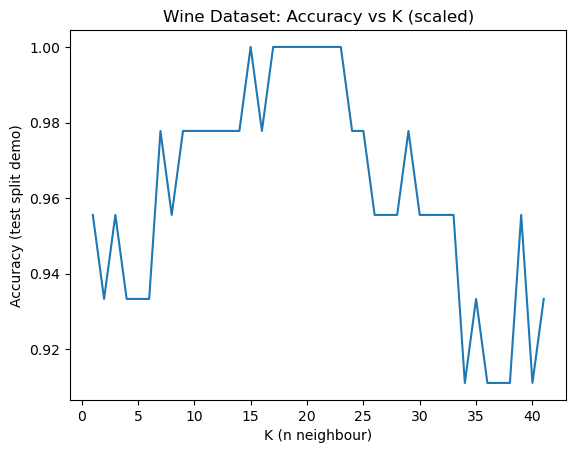

In [12]:
plt.figure()
plt.plot(list(k_values),acc)
plt.xlabel('K (n neighbour)')
plt.ylabel('Accuracy (test split demo)')
plt.title('Wine Dataset: Accuracy vs K (scaled)')
plt.show()

In [13]:
best_k = list(k_values)[int(np.argmax(acc))]
print('Best K: ', best_k)
print('Best Accuracy: ', float(np.max(acc)))

Best K:  15
Best Accuracy:  1.0


Compare distance metrics and voting weights

In [ ]:
k_demo = best_k
settings = [
    ('Euclidian (p=2), uniform', KNeighborsClassifier(n_neighbors=k_demo, metric='minkowski', p = 2, weights='uniform')),
    ('Manhattan (p=1), uniform', KNeighborsClassifier(n_neighbors=k_demo, metric='minkowski', p = 1, weights='uniform')),
    ('Euclidian (p=2), distance', KNeighborsClassifier(n_neighbors=k_demo, metric='minkowski', p = 2, weights='distance')),
    
]

rows = []
for name,knn in settings:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', knn)#
    ])
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    rows.append([name, accuracy_score(y_test,pred)])
    
pd.DataFrame(rows, columns=['Settings', 'Accuracy']).sort_values('Accuracy',ascending=False)

,Settings,Accuracy
0,"Euclidian (p=2), uniform",1.000000
2,"Euclidian (p=2), distance",1.000000
1,"Manhattan (p=1), uniform",0.977778


In [15]:
# KMM without scaling
knn_no_scale =  KNeighborsClassifier(n_neighbors=best_k)
knn_no_scale.fit(X_train,y_train)
pred_no_scale = knn_no_scale.predict(X_test)

acc_no_scale = accuracy_score(y_test,pred_no_scale)

# KNN with scaling
pred_scaled = clf.predict(X_test)
acc_scaled = accuracy_score(y_test, pred_scaled)

print('Accuracy without scaling: ', acc_no_scale)
print('Accuracy with scaling: ', acc_scaled)

Accuracy without scaling:  0.7777777777777778
Accuracy with scaling:  1.0


* Note: We have to scale before applying KNN